# Day 6: Pressure Prediction Baseline

Extends the Day 5 MLP (Cl + Cd) to predict the full pressure coefficient distribution (Cp) alongside Cl and Cd.

**Inputs:** Airfoil Geometry (198) + AoA + Reynolds + Ncrit = 201  
**Outputs:** Cl + Cd + Cp (98) = 100  

Day 5 artifacts (`baseline_mlp.pt`, `baseline_metrics.json`) are preserved and not overwritten.

In [1]:
!wget https://nasa-public-data.s3.amazonaws.com/plot3d_utilities/dataset-processed.zip
!unzip dataset-processed.zip


!python preprocess_airfoil_dataset.py \
    --input_dir datasets/standard \
    --output_dir processed_output \
    --scaler_name standard

--2026-06-21 18:03:36--  https://nasa-public-data.s3.amazonaws.com/plot3d_utilities/dataset-processed.zip
Resolving nasa-public-data.s3.amazonaws.com (nasa-public-data.s3.amazonaws.com)... 52.217.201.57, 16.15.238.35, 52.216.32.81, ...
Connecting to nasa-public-data.s3.amazonaws.com (nasa-public-data.s3.amazonaws.com)|52.217.201.57|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9188863364 (8.6G) [application/zip]
Saving to: ‘dataset-processed.zip’

dataset-processed.z 100%[===================>]   8.56G  40.5MB/s    in 3m 25s  

2026-06-21 18:07:01 (42.8 MB/s) - ‘dataset-processed.zip’ saved [9188863364/9188863364]

Archive:  dataset-processed.zip
   creating: datasets/
   creating: datasets/minmax/
  inflating: datasets/minmax/dnn_scaled_data_cp_test.pt  
  inflating: datasets/minmax/dnn_scaled_data_cp_train.pt  
  inflating: datasets/minmax/dnn_scaled_data_test.pt  
  inflating: datasets/minmax/dnn_scaled_data_train.pt  
  inflating: datasets/minmax/graph_sc

In [2]:
import numpy as np

train = np.load("processed_output/standard/main/train.npz")
val   = np.load("processed_output/standard/main/val.npz")
test  = np.load("processed_output/standard/main/test.npz")

print("Train samples:", train["cl"].shape[0])
print("Val   samples:", val["cl"].shape[0])
print("Test  samples:", test["cl"].shape[0])

Train samples: 457283
Val   samples: 80696
Test  samples: 230563


In [3]:
# Build feature matrices — same as Day 5
def make_X(split):
    return np.hstack([
        split["geometry_y"],
        split["alpha"].reshape(-1, 1),
        split["reynolds"].reshape(-1, 1),
        split["ncrit"].reshape(-1, 1)
    ])

# Updated target: Cl + Cd + Cp (100 outputs)
def make_y(split):
    return np.concatenate([
        split["cl"].reshape(-1, 1),
        split["cd"].reshape(-1, 1),
        split["cp"]
    ], axis=1)

X_train = make_X(train);  y_train = make_y(train)
X_val   = make_X(val);    y_val   = make_y(val)
X_test  = make_X(test);   y_test  = make_y(test)

print("X_train:", X_train.shape)  # (N, 201)
print("y_train:", y_train.shape)  # (N, 100)

X_train: (457283, 201)
y_train: (457283, 100)


In [4]:
import torch
from torch.utils.data import TensorDataset, DataLoader

def to_loader(X, y, batch_size=1024, shuffle=True):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)

train_loader = to_loader(X_train, y_train, shuffle=True)
val_loader   = to_loader(X_val,   y_val,   shuffle=False)

In [5]:
import torch.nn as nn

class MLP(nn.Module):
    """
    Same architecture as Day 5 except output layer is 100 (Cl + Cd + Cp[98])
    instead of 2 (Cl + Cd only).
    """
    def __init__(self, out_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(201, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, out_dim)
        )

    def forward(self, x):
        return self.net(x)

model = MLP(out_dim=100).cuda()
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=201, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=100, bias=True)
  )
)


In [6]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
best_val_loss = float("inf")

for epoch in range(20):
    # Train
    model.train()
    running_loss = 0.0
    for x, y in train_loader:
        x, y = x.cuda(), y.cuda()
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)

    # Validate
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.cuda(), y.cuda()
            val_loss += criterion(model(x), y).item()
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1:02d} | Train Loss = {train_loss:.6f} | Val Loss = {val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "baseline_cl_cd_cp.pt")

print("\nTraining complete. Best Val Loss:", best_val_loss)

Epoch 01 | Train Loss = 0.974850 | Val Loss = 0.909999
Epoch 02 | Train Loss = 0.949168 | Val Loss = 0.909148
Epoch 03 | Train Loss = 0.908419 | Val Loss = 0.749600
Epoch 04 | Train Loss = 0.896601 | Val Loss = 0.911158
Epoch 05 | Train Loss = 0.888568 | Val Loss = 0.722485
Epoch 06 | Train Loss = 0.883264 | Val Loss = 0.894944
Epoch 07 | Train Loss = 0.737881 | Val Loss = 0.594768
Epoch 08 | Train Loss = 0.830617 | Val Loss = 0.917170
Epoch 09 | Train Loss = 0.672372 | Val Loss = 0.288978
Epoch 10 | Train Loss = 0.298075 | Val Loss = 0.176931
Epoch 11 | Train Loss = 0.181309 | Val Loss = 0.161202
Epoch 12 | Train Loss = 0.341077 | Val Loss = 0.113340
Epoch 13 | Train Loss = 0.123709 | Val Loss = 0.108290
Epoch 14 | Train Loss = 0.258094 | Val Loss = 0.302482
Epoch 15 | Train Loss = 0.100867 | Val Loss = 0.068089
Epoch 16 | Train Loss = 0.138763 | Val Loss = 0.061716
Epoch 17 | Train Loss = 0.076841 | Val Loss = 0.044837
Epoch 18 | Train Loss = 0.058669 | Val Loss = 0.105943
Epoch 19 |

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import json

# Load best checkpoint
model.load_state_dict(torch.load("baseline_cl_cd_cp.pt"))
model.eval()

X_val_t = torch.tensor(X_val, dtype=torch.float32).cuda()
with torch.no_grad():
    pred = model(X_val_t).cpu().numpy()

# Slice outputs
pred_cl = pred[:, 0];   true_cl = y_val[:, 0]
pred_cd = pred[:, 1];   true_cd = y_val[:, 1]
pred_cp = pred[:, 2:];  true_cp = y_val[:, 2:]

# Overall
overall_mae  = mean_absolute_error(y_val, pred)
overall_rmse = np.sqrt(mean_squared_error(y_val, pred))
overall_r2   = r2_score(y_val, pred)

# Per-target
cl_mae  = mean_absolute_error(true_cl, pred_cl)
cl_rmse = np.sqrt(mean_squared_error(true_cl, pred_cl))
cd_mae  = mean_absolute_error(true_cd, pred_cd)
cd_rmse = np.sqrt(mean_squared_error(true_cd, pred_cd))
cp_mae  = mean_absolute_error(true_cp, pred_cp)
cp_rmse = np.sqrt(mean_squared_error(true_cp, pred_cp))

print(f"Overall  | MAE={overall_mae:.6f}  RMSE={overall_rmse:.6f}  R²={overall_r2:.6f}")
print(f"Cl       | MAE={cl_mae:.6f}  RMSE={cl_rmse:.6f}")
print(f"Cd       | MAE={cd_mae:.6f}  RMSE={cd_rmse:.6f}")
print(f"Cp       | MAE={cp_mae:.6f}  RMSE={cp_rmse:.6f}")

metrics = {
    "overall_mae": overall_mae,
    "overall_rmse": overall_rmse,
    "overall_r2": overall_r2,
    "cl_mae": cl_mae,
    "cl_rmse": cl_rmse,
    "cd_mae": cd_mae,
    "cd_rmse": cd_rmse,
    "cp_mae": cp_mae,
    "cp_rmse": cp_rmse
}

with open("baseline_cl_cd_cp_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("\nMetrics saved to baseline_cl_cd_cp_metrics.json")

Overall  | MAE=0.049674  RMSE=0.211775  R²=0.701963
Cl       | MAE=0.173591  RMSE=0.237124
Cd       | MAE=0.379665  RMSE=0.599792
Cp       | MAE=0.045042  RMSE=0.203763

Metrics saved to baseline_cl_cd_cp_metrics.json


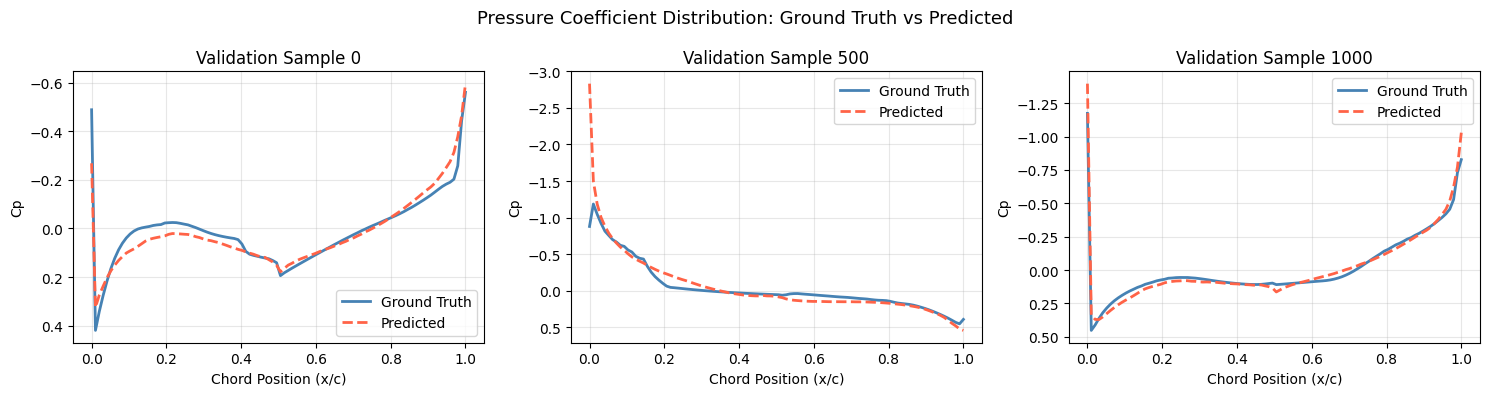

Saved: cp_comparison.png


In [8]:
import matplotlib.pyplot as plt

# Plot Cp ground truth vs prediction for 3 validation samples
sample_indices = [0, 500, 1000]
x_surface = np.linspace(0, 1, 98)  # normalized chord position

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, idx in enumerate(sample_indices):
    ax = axes[i]
    ax.plot(x_surface, true_cp[idx], label="Ground Truth", color="steelblue", linewidth=2)
    ax.plot(x_surface, pred_cp[idx], label="Predicted",    color="tomato",    linewidth=2, linestyle="--")
    ax.invert_yaxis()  # Cp convention: lower values plotted upward
    ax.set_xlabel("Chord Position (x/c)")
    ax.set_ylabel("Cp")
    ax.set_title(f"Validation Sample {idx}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Pressure Coefficient Distribution: Ground Truth vs Predicted", fontsize=13)
plt.tight_layout()
plt.savefig("cp_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cp_comparison.png")